# benchmark_procap

Artifact-light benchmark notebook for comparing ProCapNet vs CAPY evaluation outputs.

This mirrors `benchmark_yunet.ipynb` figure blocks for profile JSD/Pearson/Spearman, normalized profile metrics when pseudoreplicates are available, count metrics, fold summaries, count scatter plots, and optional stratified comparisons.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import gzip
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr
import scipy.special
import pyBigWig

warnings.filterwarnings("ignore", category=RuntimeWarning)


@dataclass
class LoadedModelData:
    label: str
    color: str
    model_name: str
    timestamp: str
    pred_log_profs: np.ndarray  # (N, 2, L)
    pred_logcounts: np.ndarray  # (N,)
    pred_profs: np.ndarray      # (N, 2, L)
    metrics: dict[str, np.ndarray]


def _find_REPO_ROOT(start = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "examples" / "procap" / "file_config.py").exists():
            return path
    raise FileNotFoundError("Could not find repo root containing examples/procap/file_config.py")


def _read_yaml(path: Path) -> dict:
    with open(path, "r") as f:
        return yaml.safe_load(f)


def _load_lines(path: str):
    if path.endswith(".gz"):
        with gzip.open(path) as f:
            return [line.decode().split() for line in f]
    with open(path) as f:
        return [line.split() for line in f]


def load_coords(peak_bed: str, window: int):
    lines = _load_lines(peak_bed)
    coords = []
    for line in lines:
        chrom, peak_start, peak_end = line[0], int(line[1]), int(line[2])
        mid = (peak_start + peak_end) // 2
        window_start = mid - window // 2
        window_end = window_start + window
        coords.append((chrom, window_start, window_end))
    return coords


def load_coords_with_summits(peak_bed: str, window: int):
    lines = _load_lines(peak_bed)
    coords = []
    for line in lines:
        chrom, peak_start, peak_end = line[0], int(line[1]), int(line[2])
        mid = (peak_start + peak_end) // 2
        window_start = mid - window // 2
        window_end = window_start + window
        summit_pos = None if line[-2] == "." else int(line[-2])
        summit_neg = None if line[-1] == "." else int(line[-1])
        coords.append((chrom, window_start, window_end, summit_pos, summit_neg))
    return coords


def _bw_values_padded(bw, chrom: str, start: int, end: int):
    chrom_sizes = bw.chroms()
    if chrom not in chrom_sizes:
        raise KeyError(f"Chromosome {chrom} not found in {bw}")

    chrom_len = chrom_sizes[chrom]
    q_start = max(start, 0)
    q_end = min(end, chrom_len)

    width = end - start
    if q_start >= q_end:
        return np.zeros(width, dtype=np.float32)

    arr = bw.values(chrom, q_start, q_end, numpy=True)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    left_pad = q_start - start
    right_pad = end - q_end
    if left_pad > 0 or right_pad > 0:
        arr = np.pad(arr, (left_pad, right_pad), mode="constant")
    return arr


def extract_observed_profiles(plus_bw_path: str, minus_bw_path: str, peak_path: str, out_window: int = 1000, verbose: bool = True):
    lines = _load_lines(peak_path)
    profiles = []

    plus_bw = pyBigWig.open(plus_bw_path, "r")
    minus_bw = pyBigWig.open(minus_bw_path, "r")
    try:
        for line in lines:
            chrom, peak_start, peak_end = line[0], int(line[1]), int(line[2])
            mid = (peak_start + peak_end) // 2
            window_start = mid - out_window // 2
            window_end = window_start + out_window

            plus = _bw_values_padded(plus_bw, chrom, window_start, window_end)
            minus = _bw_values_padded(minus_bw, chrom, window_start, window_end)
            profiles.append(np.stack([plus, minus], axis=0))
    finally:
        plus_bw.close()
        minus_bw.close()

    return np.asarray(profiles, dtype=np.float32)

def get_orientation_indexes(profiles: np.ndarray):
    return np.max(profiles.sum(axis=-1), axis=-1) / np.sum(profiles, axis=(-1, -2))


def get_shannon_entropies(profiles: np.ndarray):
    profiles_strand_sum = profiles.sum(axis=-2)
    profiles_norm = profiles_strand_sum / profiles_strand_sum.sum(axis=-1, keepdims=True)
    profiles_norm_log = np.log(profiles_norm + 1e-20)
    return -(profiles_norm * profiles_norm_log).sum(axis=-1)


def get_norm_shannon_entropies(profiles: np.ndarray, counts: np.ndarray):
    shannon_entropies = get_shannon_entropies(profiles)
    if counts.shape[-1] == 2:
        counts = counts.sum(axis=-1)
    return shannon_entropies / np.log(np.log(counts))


def _load_annotations(bed_filepath: str, label: bool = True, label_col: int = 9):
    lines = _load_lines(bed_filepath)
    coords = []
    for line in lines:
        if label:
            coords.append((line[0], int(line[1]), int(line[2]), line[label_col]))
        else:
            coords.append((line[0], int(line[1]), int(line[2])))
    return coords


def _check_list_is_sorted(a_list):
    return all(a_list[i] <= a_list[i + 1] for i in range(len(a_list) - 1))


def _labels_of_overlap(coord_a, list_b):
    assert _check_list_is_sorted(list_b), "Input intervals must be sorted"
    if len(list_b) == 0:
        return []
    if set([coord[0] for coord in list_b]) != set([coord_a[0]]):
        return []
    a_start, a_end = coord_a[1:3]
    overlap_labels = []
    b_index = 0
    while b_index < len(list_b):
        b_start, b_end, label = list_b[b_index][1:4]
        if b_start >= a_end:
            break
        if b_end <= a_start:
            b_index += 1
            continue
        overlap_labels.append(label)
        b_index += 1
    return overlap_labels


def _format_label_list(label_list):
    fixed = []
    for item in label_list:
        fixed.extend(item.split(","))
    return sorted(list(set(fixed)))


def _annots_by_chrom(annots):
    out = {}
    for annot in annots:
        out.setdefault(annot[0], []).append(annot)
    return {chrom: sorted(vals, key=lambda x: x[1]) for chrom, vals in out.items()}


def _coord_indices_by_chrom(coords):
    out = {}
    for i, coord in enumerate(coords):
        out.setdefault(coord[0], []).append((i, coord))
    return {chrom: sorted(vals, key=lambda x: x[1][1]) for chrom, vals in out.items()}


def find_peak_overlap_labels(coords, bed_file_with_labels: str):
    annots_by_chrom = _annots_by_chrom(_load_annotations(bed_file_with_labels, label=True))
    coords_by_chrom = _coord_indices_by_chrom(coords)
    overlaps = [set() for _ in coords]

    for chrom, chrom_coords in coords_by_chrom.items():
        annots = annots_by_chrom.get(chrom, [])
        left = 0
        right = 0
        for out_idx, coord in chrom_coords:
            _, start, end = coord[:3]
            while left < len(annots) and annots[left][2] <= start:
                left += 1
            while right < len(annots) and annots[right][1] < end:
                right += 1
            labels = []
            for annot in annots[left:right]:
                if annot[2] > start:
                    labels.append(annot[3])
            overlaps[out_idx] = set(_format_label_list(labels))

    all_labels = sorted({label for labels in overlaps for label in labels})
    return {label: np.array([label in labels for labels in overlaps]) for label in all_labels}


def _does_overlap_any(coord_a, list_b):
    assert _check_list_is_sorted(list_b), "Input intervals must be sorted"
    if len(list_b) == 0:
        return False
    if set([coord[0] for coord in list_b]) != set([coord_a[0]]):
        return False
    a_start, a_end = coord_a[1:3]
    b_index = 0
    while b_index < len(list_b):
        b_start, b_end = list_b[b_index][1:3]
        if b_start >= a_end:
            return False
        if b_end <= a_start:
            b_index += 1
            continue
        return True
    return False


def find_peak_overlap(coords, bed_filepath: str):
    annots_by_chrom = _annots_by_chrom(_load_annotations(bed_filepath, label=False))
    coords_by_chrom = _coord_indices_by_chrom(coords)
    overlaps = np.zeros(len(coords), dtype=bool)

    for chrom, chrom_coords in coords_by_chrom.items():
        annots = annots_by_chrom.get(chrom, [])
        left = 0
        right = 0
        for out_idx, coord in chrom_coords:
            _, start, end = coord[:3]
            while left < len(annots) and annots[left][2] <= start:
                left += 1
            while right < len(annots) and annots[right][1] < end:
                right += 1
            overlaps[out_idx] = any(annot[2] > start for annot in annots[left:right])
    return overlaps


def _clean_coord_summits(coord):
    chrom, start, end, summit_pos, summit_neg = coord[:5]
    if summit_pos is None:
        summit_pos = summit_neg
    if summit_neg is None:
        summit_neg = summit_pos
    return chrom, start, end, summit_pos, summit_neg


def get_gene_region_overlap(coords, gene_regions_files: dict[str, str]):
    summit_coords = []
    for coord in coords:
        chrom, _, _, summit_pos, summit_neg = _clean_coord_summits(coord)
        summit_coords.append((chrom, min(summit_pos, summit_neg) - 1, max(summit_pos, summit_neg)))
    return {
        region_name: find_peak_overlap(summit_coords, region_filepath)
        for region_name, region_filepath in gene_regions_files.items()
    }


def get_dist_to_TSS(coords, TSSs_bed: str):
    tsss = _load_annotations(TSSs_bed, label=False)
    chroms = sorted(list(set(coord[0] for coord in coords)))
    tsss_by_chrom = {chrom: np.array(sorted([t[1] for t in tsss if t[0] == chrom])) for chrom in chroms}
    dists = []
    for coord in coords:
        chrom, _, _, summit_pos, summit_neg = _clean_coord_summits(coord)
        midpoint = (summit_pos + summit_neg) // 2
        dists.append(np.min(np.abs(tsss_by_chrom[chrom] - midpoint)))
    return np.array(dists)


def jitter_dots(dots, jitter_by: float = 0.25, along_y: bool = False):
    offsets = dots.get_offsets()
    jittered = offsets
    if along_y:
        jittered[:, 1] += np.random.uniform(-jitter_by, jitter_by, offsets.shape[0])
    else:
        jittered[:, 0] += np.random.uniform(-jitter_by, jitter_by, offsets.shape[0])
    dots.set_offsets(jittered)


def _boxplot_stats(data):
    data = np.asarray(data)
    q1 = np.percentile(data, 25)
    med = np.percentile(data, 50)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    whislo = np.min(data[data >= q1 - 1.5 * iqr]) if np.any(data >= q1 - 1.5 * iqr) else np.min(data)
    whishi = np.max(data[data <= q3 + 1.5 * iqr]) if np.any(data <= q3 + 1.5 * iqr) else np.max(data)
    return {"q1": q1, "med": med, "q3": q3, "whislo": whislo, "whishi": whishi}


def plot_scatter_and_boxplot(data, position, color="k", dot_size=1, dot_alpha=0.05, box_linewidth=1.5, box_whisker_linewidth=1, white_dot_size=3):
    if len(data) < 200:
        dot_alpha *= 2
    if len(data) < 100:
        dot_alpha *= 2
    dots = plt.scatter(data, [position] * len(data), color=color, s=dot_size, alpha=dot_alpha, linewidths=0)
    jitter_dots(dots, along_y=True, jitter_by=0.2)

    bps = _boxplot_stats(data)
    plt.plot([bps["whislo"], bps["whishi"]], [position + 0.35] * 2, linewidth=box_whisker_linewidth, color=color, alpha=1, zorder=30)
    plt.plot([bps["q1"], bps["q3"]], [position + 0.33] * 2, linewidth=box_linewidth, color=color, alpha=1, zorder=28)
    plt.plot([bps["q1"], bps["q3"]], [position + 0.38] * 2, linewidth=box_linewidth, color=color, alpha=1, zorder=29)
    black_dot_size = 8 if white_dot_size == 3 else white_dot_size * 2.5
    plt.scatter(bps["med"], [position + 0.35], s=black_dot_size, color="k", zorder=31)
    plt.scatter(bps["med"], [position + 0.35], s=white_dot_size, color="white", zorder=32)


def multinomial_log_probs(category_log_probs, trials, query_counts, return_cross_entropy=True):
    log_n_fact = scipy.special.gammaln(trials + 1)
    log_counts_fact = scipy.special.gammaln(query_counts + 1)
    log_counts_fact_sum = np.sum(log_counts_fact, axis=-1)
    log_prob_pows = category_log_probs * query_counts
    log_prob_pows_sum = np.sum(log_prob_pows, axis=-1)
    log_prob = log_n_fact - log_counts_fact_sum + log_prob_pows_sum
    if return_cross_entropy:
        cross_ent = (-log_prob_pows_sum) / trials
        return log_prob, cross_ent
    return log_prob


def _find_reorder_indices(merged_coords, fold_coords):
    pos = {}
    for i, c in enumerate(fold_coords):
        pos.setdefault(c, []).append(i)
    use = {k: 0 for k in pos}
    idx = []
    for c in merged_coords:
        if c not in pos:
            raise KeyError(f"Coordinate not found in fold test set union: {c}")
        j = use[c]
        if j >= len(pos[c]):
            raise IndexError(f"Coordinate occurrence exhausted for: {c}")
        idx.append(pos[c][j])
        use[c] += 1
    return np.array(idx, dtype=int)


def calc_profile_jsd_pearson_spearman(profs1: np.ndarray, profs2: np.ndarray):
    assert profs1.shape == profs2.shape, (profs1.shape, profs2.shape)
    jsds, pears, spears = [], [], []
    for i, (p1, p2) in enumerate(zip(profs1, profs2)):
        p1f = np.asarray(p1, dtype=np.float64).flatten()
        p2f = np.asarray(p2, dtype=np.float64).flatten()
        if not np.isfinite(p1f).all() or not np.isfinite(p2f).all():
            raise ValueError(f"Non-finite profile values at index {i}")
        if p1f.min() < -1e-6 or p2f.min() < -1e-6:
            raise ValueError(
                f"JSD requires non-negative profiles; index {i} has "
                f"mins ({p1f.min():.4g}, {p2f.min():.4g})"
            )
        p1f = np.clip(p1f, 0, None)
        p2f = np.clip(p2f, 0, None)
        if p1f.sum() == 0 or p2f.sum() == 0:
            jsd = np.nan
        else:
            jsd = jensenshannon(p1f, p2f, base=2)
        if np.isinf(jsd):
            raise ValueError(
                f"Infinite JSD at index {i}; sums=({p1f.sum():.4g}, {p2f.sum():.4g}), "
                f"maxes=({p1f.max():.4g}, {p2f.max():.4g})"
            )
        jsds.append(jsd)
        pears.append(np.corrcoef(p1f, p2f)[0, 1])
        spears.append(spearmanr(p1f, p2f).correlation)
    return np.array(jsds), np.array(pears), np.array(spears)


def normalize_metric(metrics_pred_vs_obs, metrics_upper_bound, metrics_lower_bound, bigger_is_worse=False):
    norm = (metrics_pred_vs_obs - metrics_lower_bound) / (metrics_upper_bound - metrics_lower_bound)
    if bigger_is_worse:
        norm = 1 - norm
    return np.clip(norm, 0, 1)


def _per_fold_means(values, fold_labels):
    fold_ids = sorted(list(set(fold_labels)))
    return np.array([np.mean(values[np.array(fold_labels) == f]) for f in fold_ids]), np.array(fold_ids)


In [2]:
# -----------------------------
# User config
# -----------------------------
from pathlib import Path

proj_dir = Path("/grid/koo/home/shared/capybara/procap")
cell_type = "K562"
data_type = "procap"
split = "val"
folds = [1, 2, 3, 4, 5, 6, 7]
rc_augmented = True

# One timestamp per model, reused across all folds.
# Update these timestamps to the runs you want to compare.
model_specs = [
    {"label": "ProCapNet", "model_name": "procapnet", "timestamp": "260509", "color": "#808080"},
    {"label": "CAPY", "model_name": "capy", "timestamp": "260511", "color": "#1565C0"},
]

figures_subdir = "examples/procap/figures_benchmark_procap"


In [3]:
# Resolve repo + load dependencies

REPO_ROOT = _find_REPO_ROOT()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

EXAMPLES_PROCAP_DIR = REPO_ROOT / "examples" / "procap"
if str(EXAMPLES_PROCAP_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_PROCAP_DIR))

from file_config import FoldFilesConfig

figures_dir = REPO_ROOT / figures_subdir
figures_dir.mkdir(parents=True, exist_ok=True)


def get_fold_configs(model_name: str, timestamp: str):
    return [
        FoldFilesConfig.create(
            proj_dir=proj_dir,
            cell_type=cell_type,
            data_type=data_type,
            fold=int(f),
            model_name=model_name,
            timestamp=timestamp,
            use_unmappability_mask=False,
        )
        for f in folds
    ]


def split_peak_path(cfg, split_name: str):
    if split_name == "train":
        return cfg.train_peak_path
    if split_name == "val":
        return cfg.val_peak_path
    if split_name == "test":
        return cfg.test_peak_path
    if split_name == "all":
        return cfg.all_peak_path
    raise ValueError(f"Unsupported split: {split_name}")


def pred_paths(cfg):
    base = Path(cfg.eval_dir)
    rc_suffix = "_rc" if rc_augmented else ""
    return (
        base / f"{cell_type}_log_pred_profiles{rc_suffix}_{split}.npy",
        base / f"{cell_type}_log_pred_counts{rc_suffix}_{split}.npy",
    )


In [4]:
# Load observed data + pseudoreps + baselines

ref_fold_cfgs = get_fold_configs(model_specs[0]["model_name"], model_specs[0]["timestamp"])
ref_cfg = ref_fold_cfgs[0]
params = _read_yaml(Path(ref_cfg.params_path))
out_window = int(params["dataset"]["output_length"])

fold_split_coords = []
fold_labels_unsorted = []
for cfg in ref_fold_cfgs:
    peak_path = split_peak_path(cfg, split)
    c = load_coords(str(peak_path), out_window)
    fold_split_coords.extend(c)
    fold_labels_unsorted.extend([int(cfg.fold)] * len(c))

if split == "all":
    sort_order = np.arange(len(fold_split_coords), dtype=int)
    fold_labels = np.array(fold_labels_unsorted, dtype=int)
    all_coords = load_coords_with_summits(str(ref_cfg.all_peak_path), out_window)
else:
    merged_coords = load_coords(str(ref_cfg.all_peak_path), out_window)
    sort_order = _find_reorder_indices(merged_coords, fold_split_coords)
    fold_labels = np.array(fold_labels_unsorted, dtype=int)[sort_order]
    all_coords = load_coords_with_summits(str(ref_cfg.all_peak_path), out_window)

true_profs, true_counts = [], []
pseudorep1_profs, pseudorep2_profs = [], []
have_pseudoreps = True
for cfg in ref_fold_cfgs:
    peak_path = split_peak_path(cfg, split)
    obs = extract_observed_profiles(
        str(cfg.plus_bw_path),
        str(cfg.minus_bw_path),
        str(peak_path),
        out_window=out_window,
        verbose=True,
    )
    true_profs.extend(obs)
    true_counts.extend(obs.sum(axis=-1).squeeze())

    data_dir = Path(cfg.processed_dir)
    pseudorep_paths = [
        data_dir / "pseudorep1.pos.bigWig",
        data_dir / "pseudorep1.neg.bigWig",
        data_dir / "pseudorep2.pos.bigWig",
        data_dir / "pseudorep2.neg.bigWig",
    ]
    if all(path.exists() for path in pseudorep_paths):
        pseudorep1_profs.extend(extract_observed_profiles(
            str(data_dir / "pseudorep1.pos.bigWig"),
            str(data_dir / "pseudorep1.neg.bigWig"),
            str(peak_path),
            out_window=out_window,
            verbose=True,
        ))
        pseudorep2_profs.extend(extract_observed_profiles(
            str(data_dir / "pseudorep2.pos.bigWig"),
            str(data_dir / "pseudorep2.neg.bigWig"),
            str(peak_path),
            out_window=out_window,
            verbose=True,
        ))
    else:
        have_pseudoreps = False

true_profs = np.array(true_profs)[sort_order]
true_counts = np.array(true_counts)[sort_order]
if have_pseudoreps:
    pseudorep1_profs = np.array(pseudorep1_profs)[sort_order]
    pseudorep2_profs = np.array(pseudorep2_profs)[sort_order]

folds_here = sorted(list(set(fold_labels)))
avg_profiles = []
for fold in folds_here:
    in_train_val = np.array([f != fold for f in fold_labels])
    avg_profiles.append(np.mean(true_profs[in_train_val], axis=0))
avg_profiles_by_fold = {fold: avg_profiles[i] for i, fold in enumerate(folds_here)}
avg_profiles_over_folds = np.array([avg_profiles_by_fold[f] for f in fold_labels])

if have_pseudoreps:
    jsd_pseudo, pear_pseudo, spear_pseudo = calc_profile_jsd_pearson_spearman(pseudorep1_profs, pseudorep2_profs)
    jsd_avg, pear_avg, spear_avg = calc_profile_jsd_pearson_spearman(true_profs, avg_profiles_over_folds)
else:
    jsd_pseudo = pear_pseudo = spear_pseudo = None
    jsd_avg = pear_avg = spear_avg = None
    print("Pseudoreplicate BigWigs not found; normalized metrics and pseudorep CDF baselines will be skipped.")

print("Loaded observed arrays")
print("true_profs:", true_profs.shape, "true_counts:", true_counts.shape)
print("have_pseudoreps:", have_pseudoreps)


Loaded observed arrays
true_profs: (30534, 2, 1000) true_counts: (30534, 2)
have_pseudoreps: True


In [5]:
# Load model predictions + compute metrics

model_results = {}

for spec in model_specs:
    label = spec["label"]
    color = spec.get("color", "#1f77b4")
    model_name = spec["model_name"]
    timestamp = spec["timestamp"]
    fold_cfgs = get_fold_configs(model_name, timestamp)
    model_params = _read_yaml(Path(fold_cfgs[0].params_path))
    model_out_window = int(model_params["dataset"]["output_length"])
    if model_out_window != out_window:
        raise ValueError(
            f"{label} has output_length={model_out_window}, expected {out_window}. "
            "All benchmarked models must share output_length."
        )

    logp_all, logc_all = [], []
    for cfg in fold_cfgs:
        p_prof, p_cnt = pred_paths(cfg)
        if not p_prof.exists() or not p_cnt.exists():
            raise FileNotFoundError(
                f"Missing prediction files for {label}, fold={cfg.fold}:\n"
                f"  {p_prof}\n"
                f"  {p_cnt}\n"
                f"Run examples/procap/evaluate.py with --save_predictions"
                + (" --reverse_complement." if rc_augmented else ".")
            )
        logp_all.append(np.load(p_prof))
        logc_all.append(np.load(p_cnt).squeeze())

    logp = np.concatenate(logp_all, axis=0)[sort_order]
    logc = np.concatenate(logc_all, axis=0)[sort_order]
    if logp.shape != true_profs.shape:
        raise ValueError(f"{label} profile shape {logp.shape} does not match observed shape {true_profs.shape}")
    if len(logc) != len(true_counts):
        raise ValueError(f"{label} count length {len(logc)} does not match observed length {len(true_counts)}")
    probs = np.exp(logp)

    jsd, pear, spear = calc_profile_jsd_pearson_spearman(true_profs, probs)
    metrics = {
        "profile_jsd": jsd,
        "profile_pearson": pear,
        "profile_spearman": spear,
    }
    if have_pseudoreps:
        metrics.update({
            "norm_profile_jsd": normalize_metric(jsd, jsd_pseudo, jsd_avg, bigger_is_worse=True),
            "norm_profile_pearson": normalize_metric(pear, pear_pseudo, pear_avg),
            "norm_profile_spearman": normalize_metric(spear, spear_pseudo, spear_avg),
        })

    true_counts_1d = true_counts.sum(axis=-1).squeeze()
    pred_logcounts_1d = logc.squeeze()
    count_pear = np.corrcoef(pred_logcounts_1d, np.log1p(true_counts_1d))[0, 1]
    count_spear = spearmanr(pred_logcounts_1d, np.log1p(true_counts_1d)).correlation
    count_mse = np.mean((pred_logcounts_1d - np.log1p(true_counts_1d)) ** 2)
    ss_res = np.sum((np.log1p(true_counts_1d) - pred_logcounts_1d) ** 2)
    ss_tot = np.sum((np.log1p(true_counts_1d) - np.mean(np.log1p(true_counts_1d))) ** 2)
    count_r2 = 1 - (ss_res / ss_tot)
    metrics.update({
        "count_pearson_log1p": np.array([count_pear]),
        "count_spearman_log1p": np.array([count_spear]),
        "count_mse_log1p": np.array([count_mse]),
        "count_r2_log1p": np.array([count_r2]),
    })

    model_results[label] = LoadedModelData(
        label=label,
        color=color,
        model_name=model_name,
        timestamp=timestamp,
        pred_log_profs=logp,
        pred_logcounts=logc,
        pred_profs=probs,
        metrics=metrics,
    )

print("Loaded model predictions for:", ", ".join(model_results.keys()))


Loaded model predictions for: ProCapNet, CAPY


In [6]:
# -----------------------------
# Summary table
# -----------------------------
rows = []
for label, d in model_results.items():
    row = {
        "model": label,
        "model_name": d.model_name,
        "timestamp": d.timestamp,
        "profile_jsd_mean": float(np.nanmean(d.metrics["profile_jsd"])),
        "profile_pearson_mean": float(np.nanmean(d.metrics["profile_pearson"])),
        "profile_spearman_mean": float(np.nanmean(d.metrics["profile_spearman"])),
        "count_pearson_log1p": float(d.metrics["count_pearson_log1p"][0]),
        "count_spearman_log1p": float(d.metrics["count_spearman_log1p"][0]),
        "count_mse_log1p": float(d.metrics["count_mse_log1p"][0]),
        "count_r2_log1p": float(d.metrics["count_r2_log1p"][0]),
    }
    if have_pseudoreps:
        row.update({
            "norm_profile_jsd_mean": float(np.nanmean(d.metrics["norm_profile_jsd"])),
            "norm_profile_pearson_mean": float(np.nanmean(d.metrics["norm_profile_pearson"])),
            "norm_profile_spearman_mean": float(np.nanmean(d.metrics["norm_profile_spearman"])),
        })
    rows.append(row)
summary_df = pd.DataFrame(rows).sort_values("model")
summary_df


,model,model_name,timestamp,profile_jsd_mean,profile_pearson_mean,profile_spearman_mean,count_pearson_log1p,count_spearman_log1p,count_mse_log1p,count_r2_log1p,norm_profile_jsd_mean,norm_profile_pearson_mean,norm_profile_spearman_mean
1,CAPY,capy,260511,0.654319,0.593212,0.303181,0.739224,0.763813,1.052477,0.332263,0.348508,0.645388,0.480047
0,ProCapNet,procapnet,260509,0.692534,0.541695,0.291945,0.718148,0.727234,0.874560,0.445141,0.444739,0.577993,0.444839


In [7]:
# -----------------------------
# Validation: Profile Spearman
# -----------------------------
first_label = model_specs[0]["label"]
first_data = model_results[first_label]
idx = np.isfinite(first_data.metrics["profile_spearman"])
validation = {
    "model": first_label,
    "direct_spearman": float(np.nanmean(first_data.metrics["profile_spearman"][idx])),
    "num_finite_examples": int(idx.sum()),
    "num_total_examples": int(len(idx)),
}
validation


{'model': 'ProCapNet',
 'direct_spearman': 0.2919451125315006,
 'num_finite_examples': 30534,
 'num_total_examples': 30534}

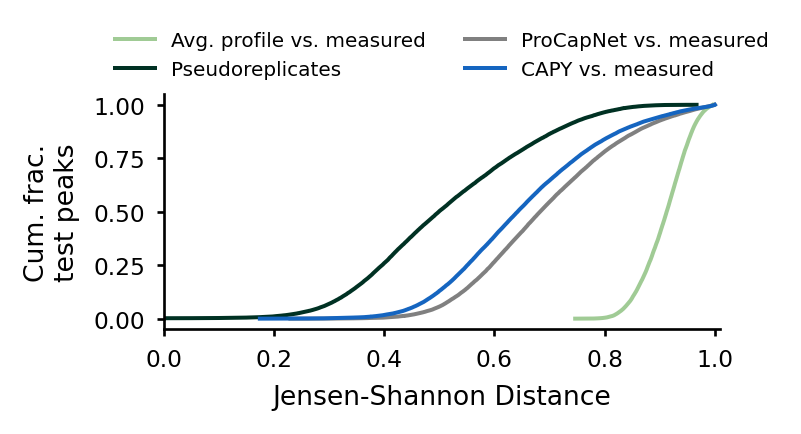

saved: /grid/koo/home/nagai/projects/capybara/examples/procap/figures_benchmark_procap/cmp_cdf_profile_jsd.pdf


In [8]:
# -----------------------------
# Figure block: CDF overlays
# -----------------------------
def plot_cdf(metric_key, xlabel, baseline_avg=None, baseline_pseudo=None, out_name=None, xlim=None):
    fig, ax = plt.subplots(figsize=(2.9, 2.0), dpi=240)
    if baseline_avg is not None:
        arr = np.sort(np.asarray(baseline_avg, dtype=float)); arr = arr[np.isfinite(arr)]
        ax.plot(arr, np.arange(1, len(arr) + 1) / len(arr), color="#A0CB95", linewidth=1.2, label="Avg. profile vs. measured")
    if baseline_pseudo is not None:
        arr = np.sort(np.asarray(baseline_pseudo, dtype=float)); arr = arr[np.isfinite(arr)]
        ax.plot(arr, np.arange(1, len(arr) + 1) / len(arr), color="#003123", linewidth=1.2, label="Pseudoreplicates")
    for label, d in model_results.items():
        arr = np.sort(np.asarray(d.metrics[metric_key], dtype=float)); arr = arr[np.isfinite(arr)]
        ax.plot(arr, np.arange(1, len(arr) + 1) / len(arr), color=d.color, linewidth=1.2, label=f"{label} vs. measured")
    ax.set_xlabel(xlabel, fontsize=8); ax.set_ylabel("Cum. frac.\ntest peaks", fontsize=8)
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.spines[["top", "right"]].set_visible(False); ax.tick_params(length=2, labelsize=7)
    ax.legend(frameon=False, fontsize=6, ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.03), borderaxespad=0.0)
    out = figures_dir / out_name
    fig.subplots_adjust(left=0.18, right=0.98, bottom=0.23, top=0.72)
    # fig.savefig(out, bbox_inches="tight", pad_inches=0.08)
    plt.show(); print("saved:", out)

plot_cdf("profile_jsd", "Jensen-Shannon Distance", jsd_avg, jsd_pseudo, "cmp_cdf_profile_jsd.pdf", xlim=(0, 1.01))
# plot_cdf("profile_pearson", "Profile Pearson Corr.", pear_avg, pear_pseudo, "cmp_cdf_profile_pearson.pdf", xlim=(-0.15, 1.02))
# plot_cdf("profile_spearman", "Profile Spearman Corr.", spear_avg, spear_pseudo, "cmp_cdf_profile_spearman.pdf", xlim=(-0.15, 1.02))


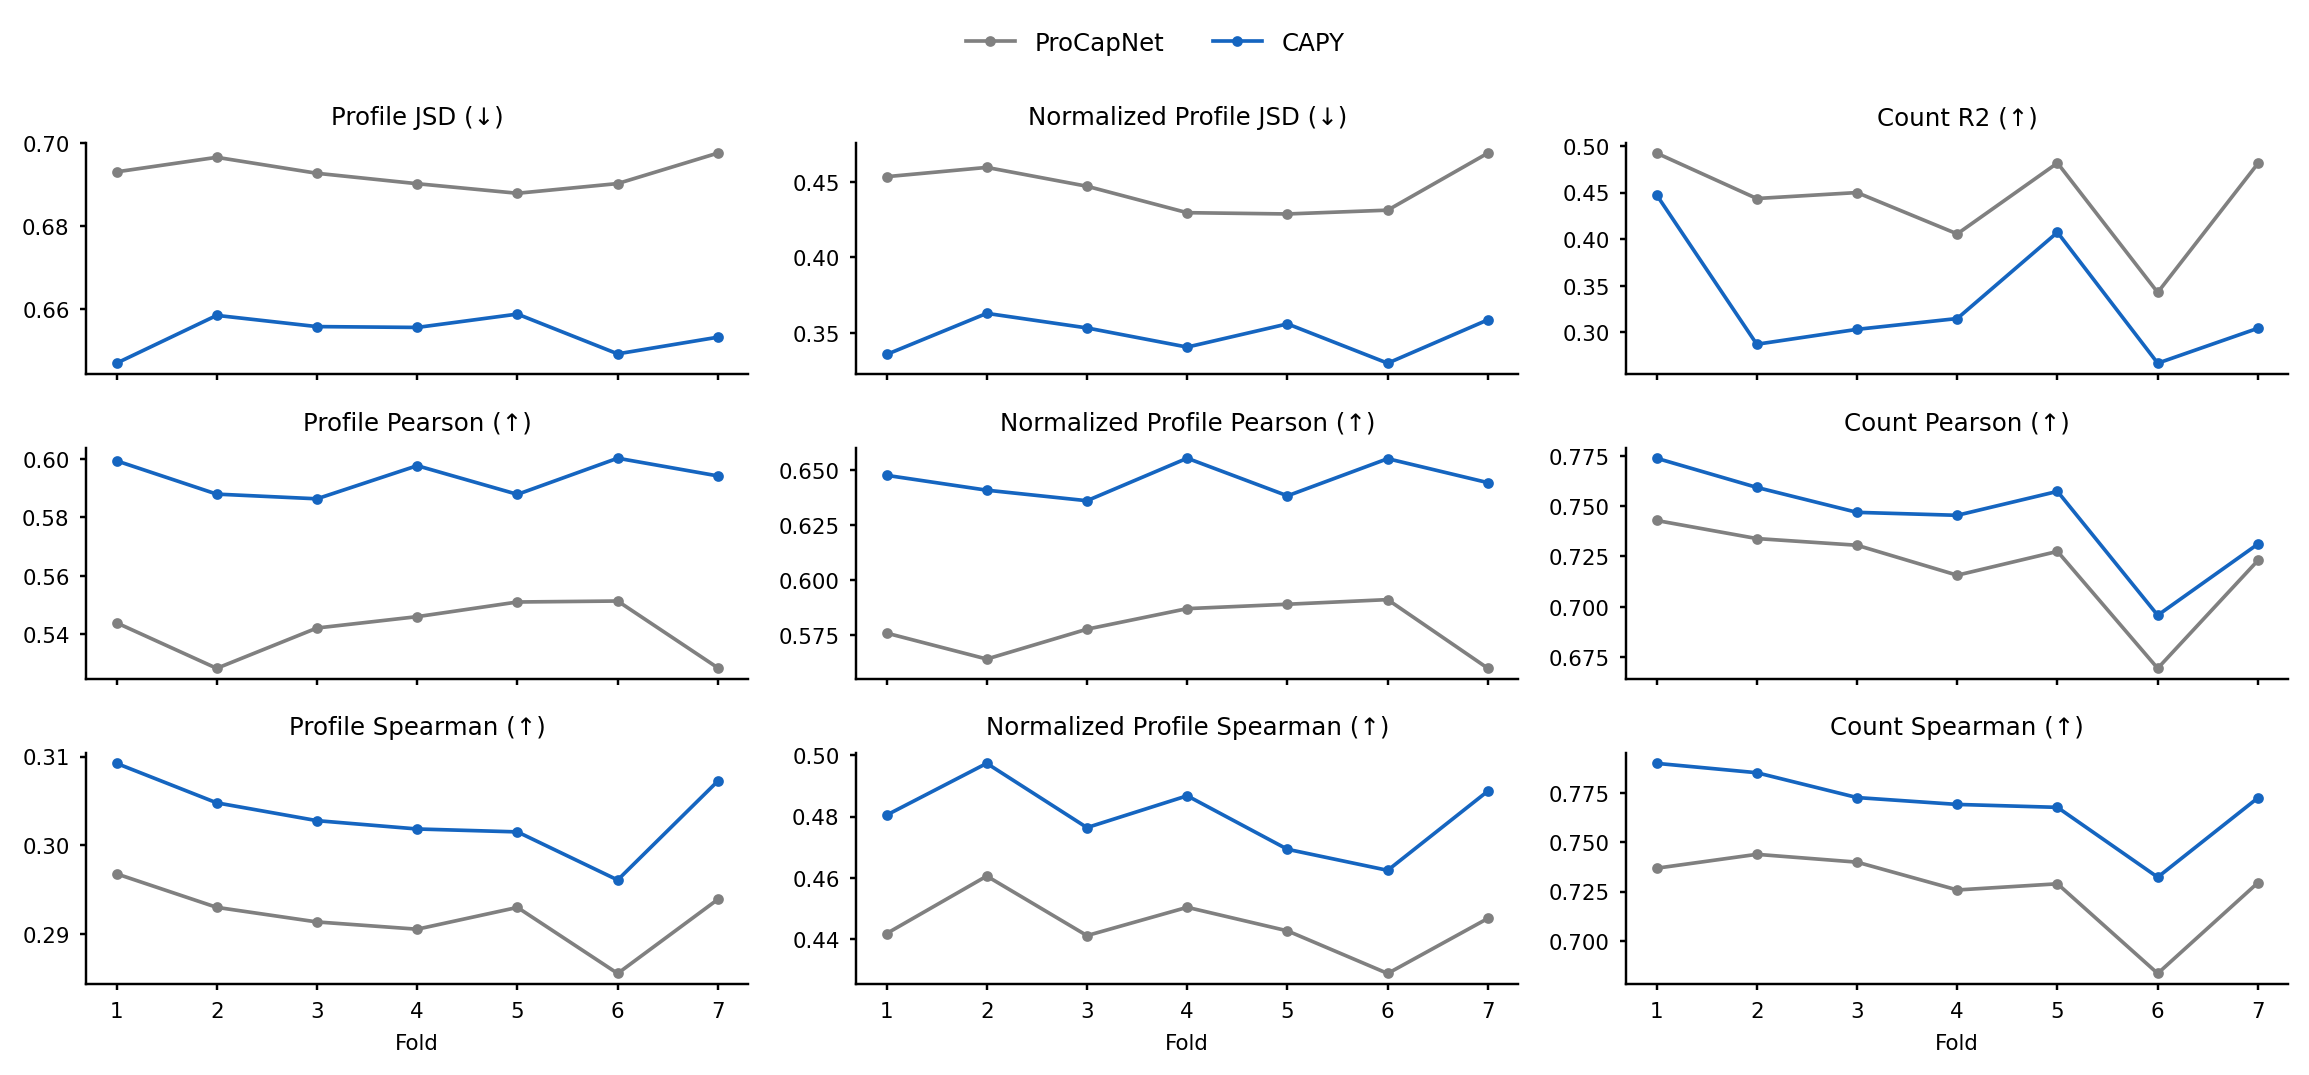

saved: /grid/koo/home/nagai/projects/capybara/examples/procap/figures_benchmark_procap/cmp_fold_metrics.pdf


In [9]:
# -----------------------------
# Figure block: Fold-level summaries
# -----------------------------
fold_records = []
metric_keys = [
    "profile_jsd", "profile_pearson", "profile_spearman",
    "norm_profile_jsd", "norm_profile_pearson", "norm_profile_spearman",
    "count_r2_log1p", "count_pearson_log1p", "count_spearman_log1p",
]
metric_grid = [
    ("profile_jsd", "norm_profile_jsd", "count_r2_log1p"),
    ("profile_pearson", "norm_profile_pearson", "count_pearson_log1p"),
    ("profile_spearman", "norm_profile_spearman", "count_spearman_log1p"),
]
metrics2title = {
    "profile_jsd": "Profile JSD (↓)",
    "profile_pearson": "Profile Pearson (↑)",
    "profile_spearman": "Profile Spearman (↑)",
    "norm_profile_jsd": "Normalized Profile JSD (↓)",
    "norm_profile_pearson": "Normalized Profile Pearson (↑)",
    "norm_profile_spearman": "Normalized Profile Spearman (↑)",
    "count_r2_log1p": "Count R2 (↑)",
    "count_pearson_log1p": "Count Pearson (↑)",
    "count_spearman_log1p": "Count Spearman (↑)",
}
for label, d in model_results.items():
    true_counts_log1p = np.log1p(true_counts.sum(axis=-1).squeeze())
    pred_logcounts_1d = d.pred_logcounts.squeeze()
    for mk in ["profile_jsd", "profile_pearson", "profile_spearman", "norm_profile_jsd", "norm_profile_pearson", "norm_profile_spearman"]:
        means, ids = _per_fold_means(d.metrics[mk], fold_labels)
        for f, m in zip(ids, means):
            fold_records.append({"model": label, "metric": mk, "fold": int(f), "value": float(m)})
    for f in sorted(set(fold_labels)):
        mask = np.array(fold_labels) == f
        y_true = true_counts_log1p[mask]
        y_pred = pred_logcounts_1d[mask]
        count_pear = np.corrcoef(y_pred, y_true)[0, 1]
        count_spear = spearmanr(y_pred, y_true).correlation
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        count_r2 = 1 - (ss_res / ss_tot)
        fold_records.extend([
            {"model": label, "metric": "count_r2_log1p", "fold": int(f), "value": float(count_r2)},
            {"model": label, "metric": "count_pearson_log1p", "fold": int(f), "value": float(count_pear)},
            {"model": label, "metric": "count_spearman_log1p", "fold": int(f), "value": float(count_spear)},
        ])
fold_df = pd.DataFrame(fold_records)

fig, axes = plt.subplots(len(metric_grid), 3, figsize=(10.6, 4.8), dpi=220, sharex=True)
fold_ids = sorted(set(fold_labels))
for row, metric_row in enumerate(metric_grid):
    for col, mk in enumerate(metric_row):
        ax = axes[row, col]
        sub = fold_df[fold_df.metric == mk]
        for label in model_results.keys():
            ss = sub[sub.model == label].sort_values("fold")
            color = model_results[label].color
            ax.plot(ss["fold"], ss["value"], marker="o", linewidth=1.2, markersize=2.5, color=color, label=label)
        ax.set_title(metrics2title[mk], fontsize=8)
        if row == len(metric_grid) - 1:
            ax.set_xlabel("Fold", fontsize=7)
        ax.set_xticks(fold_ids)
        ax.tick_params(length=2, labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8, ncol=len(labels), loc="upper center", bbox_to_anchor=(0.5, 1.02))
out = figures_dir / "cmp_fold_metrics.pdf"
plt.tight_layout(rect=(0, 0, 1, 0.96), w_pad=1.0, h_pad=1.0)
# plt.savefig(out)
plt.show(); print("saved:", out)

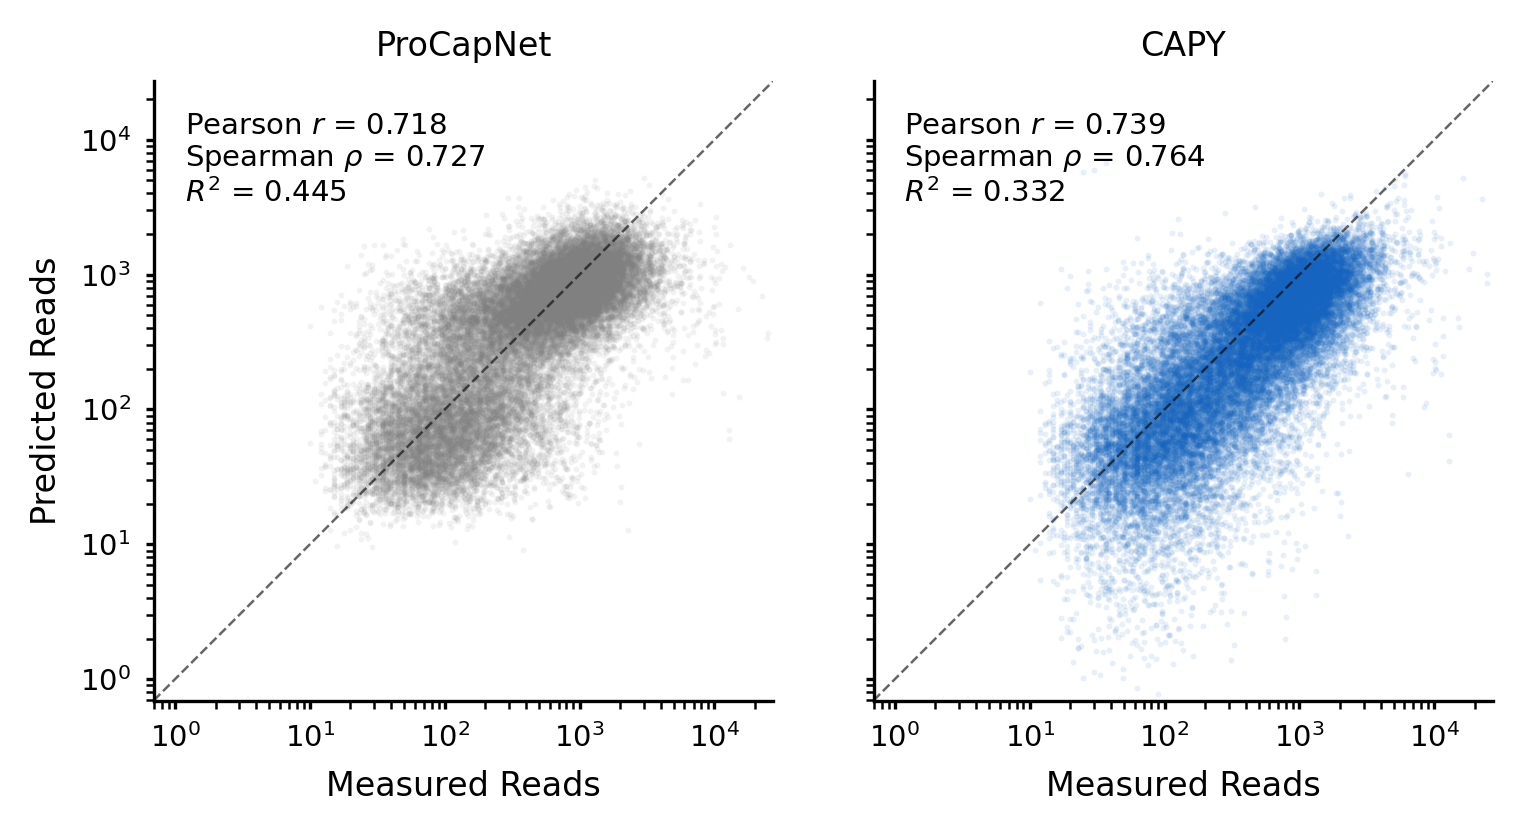

saved: /grid/koo/home/nagai/projects/capybara/examples/procap/figures_benchmark_procap/cmp_counts_scatter.pdf


In [18]:
# -----------------------------
# Figure block: Count comparison
# -----------------------------
true_counts_1d = true_counts.sum(axis=-1).squeeze()
models = list(model_results.items())
pred_counts_by_model = {
    label: np.exp(d.pred_logcounts.squeeze())
    for label, d in models
}
positive_values = [true_counts_1d[true_counts_1d > 0]]
positive_values.extend(arr[arr > 0] for arr in pred_counts_by_model.values())
positive_values = np.concatenate(positive_values)
count_lim = (positive_values.min() * 0.9, positive_values.max() * 1.10)

fig, axes = plt.subplots(1, len(models), figsize=(2.7 * len(models), 2.7), dpi=300, sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (label, d) in zip(axes, models):
    pred_logcounts_1d = d.pred_logcounts.squeeze()
    pred_counts = pred_counts_by_model[label]
    ax.scatter(true_counts_1d, pred_counts, alpha=0.1, s=2, color=d.color, linewidths=0)
    ax.plot(count_lim, count_lim, color="black", linewidth=0.6, linestyle="--", alpha=0.6)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(count_lim); ax.set_ylim(count_lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(label, fontsize=8)
    ax.set_xlabel("Measured Reads", fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel("Predicted Reads", fontsize=8)
    pearson_r = d.metrics["count_pearson_log1p"][0]
    spearman_rho = d.metrics["count_spearman_log1p"][0]
    r2 = d.metrics["count_r2_log1p"][0]
    ax.text(
        0.05, 0.95,
        f"Pearson $r$ = {pearson_r:0.3f}\nSpearman $\\rho$ = {spearman_rho:0.3f}\n$R^2$ = {r2:0.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=7,
        linespacing=1.15,
    )
    ax.spines[["top", "right"]].set_visible(False); ax.tick_params(length=2, labelsize=7)
out = figures_dir / "cmp_counts_scatter.pdf"
plt.tight_layout(w_pad=0.6)
# plt.savefig(out)
plt.show(); print("saved:", out)


/tmp/ipykernel_3942028/3781798808.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, labels=labels, patch_artist=True, showfliers=False, widths=0.55)
/tmp/ipykernel_3942028/3781798808.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, labels=labels, patch_artist=True, showfliers=False, widths=0.55)
/tmp/ipykernel_3942028/3781798808.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, labels=labels, patch_artist=True, showfliers=False, widths=0.55)
/tmp/ipykernel_3942028/3781798808.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of 

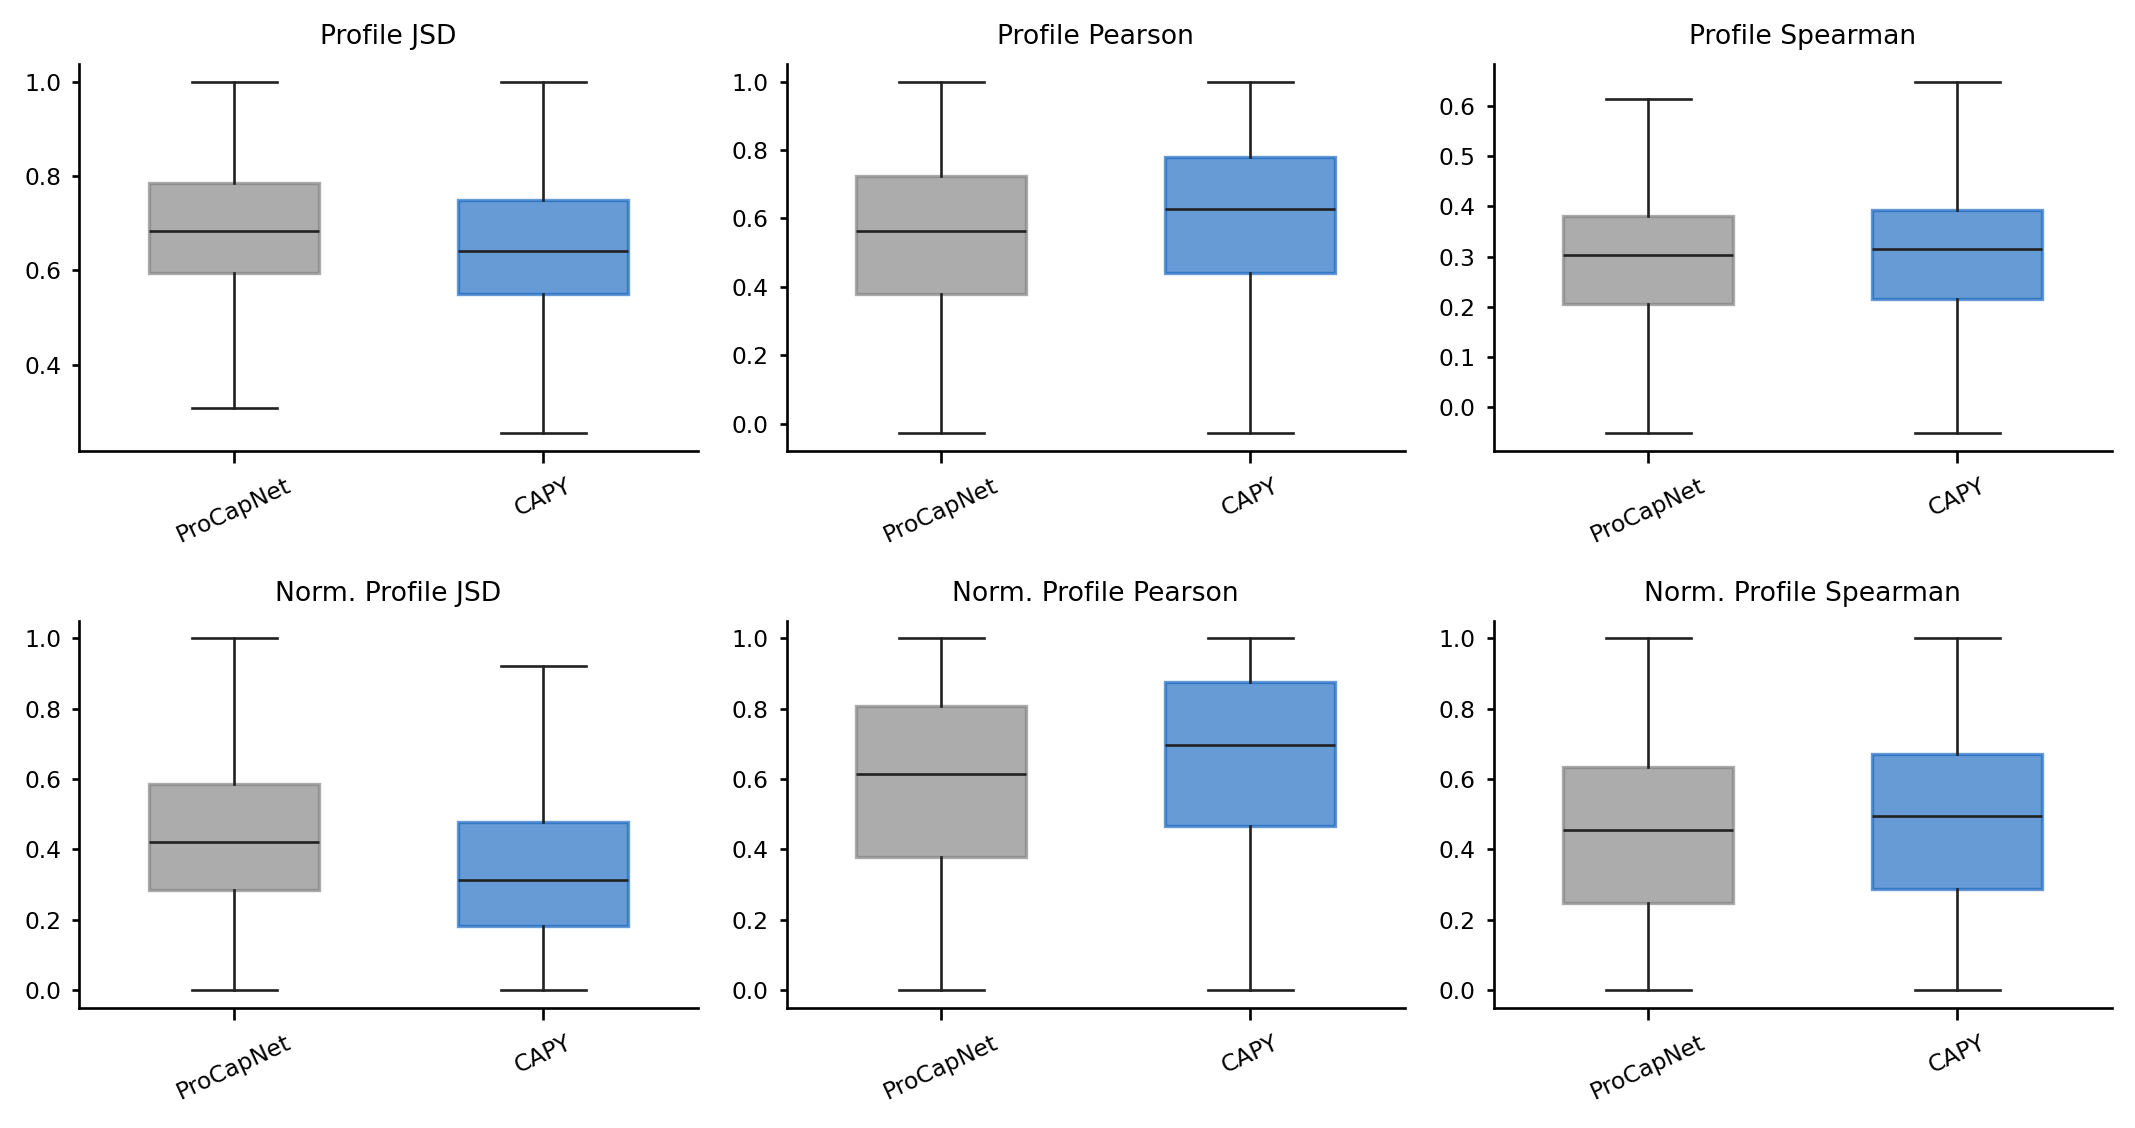

saved: /grid/koo/home/nagai/projects/capybara/examples/procap/figures_benchmark_procap/cmp_profile_metric_boxplots.pdf


In [11]:
# -----------------------------
# Figure block: Profile metric boxplots
# -----------------------------
profile_box_metrics = [
    ("profile_jsd", "Profile JSD"),
    ("profile_pearson", "Profile Pearson"),
    ("profile_spearman", "Profile Spearman"),
]
if have_pseudoreps:
    profile_box_metrics.extend([
        ("norm_profile_jsd", "Norm. Profile JSD"),
        ("norm_profile_pearson", "Norm. Profile Pearson"),
        ("norm_profile_spearman", "Norm. Profile Spearman"),
    ])

ncols = 3
nrows = int(np.ceil(len(profile_box_metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(9.0, 2.4 * nrows), dpi=240)
axes = np.asarray(axes).reshape(nrows, ncols)
labels = list(model_results.keys())
for ax, (mk, title) in zip(axes.ravel(), profile_box_metrics):
    values = []
    colors = []
    for label in labels:
        arr = np.asarray(model_results[label].metrics[mk], dtype=float)
        values.append(arr[np.isfinite(arr)])
        colors.append(model_results[label].color)
    bp = ax.boxplot(values, labels=labels, patch_artist=True, showfliers=False, widths=0.55)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
        patch.set_edgecolor(color)
    for key in ["whiskers", "caps", "medians"]:
        for artist in bp[key]:
            artist.set_color("#222222")
            artist.set_linewidth(0.8)
    ax.set_title(title, fontsize=8)
    ax.tick_params(axis="x", labelrotation=25, labelsize=7)
    ax.tick_params(axis="y", length=2, labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.ravel()[len(profile_box_metrics):]:
    ax.axis("off")
out = figures_dir / "cmp_profile_metric_boxplots.pdf"
plt.tight_layout(w_pad=1.0, h_pad=1.0)
plt.savefig(out, bbox_inches="tight", pad_inches=0.08)
plt.show(); print("saved:", out)


In [12]:
# # -----------------------------
# # Figure block: OI/NSI covariates
# # -----------------------------
# ois = get_orientation_indexes(true_profs)
# nsis = get_norm_shannon_entropies(true_profs, true_counts)


# def plot_cov_overlay(metric_key, covariate, xlabel, ylabel, out_name):
#     plt.figure(figsize=(2.3, 1.8), dpi=240)
#     for label, d in model_results.items():
#         plt.scatter(covariate, d.metrics[metric_key], s=2, alpha=0.04, linewidths=0, color=d.color, label=label)
#     plt.xlabel(xlabel, fontsize=8); plt.ylabel(ylabel, fontsize=8)
#     ax = plt.gca(); ax.spines[["top", "right"]].set_visible(False); ax.tick_params(length=2, labelsize=7)
#     plt.legend(frameon=False, fontsize=6, ncol=2, loc="best")
#     out = figures_dir / out_name
#     plt.savefig(out, dpi=300, bbox_inches="tight", pad_inches=0)
#     plt.show(); print("saved:", out)

# # Uncomment as needed.
# # plot_cov_overlay("profile_jsd", ois, "Orientation Index", "Profile JSD", "cmp_oi_vs_profile_jsd.png")
# # plot_cov_overlay("profile_pearson", ois, "Orientation Index", "Profile Pearson", "cmp_oi_vs_profile_pearson.png")
# # plot_cov_overlay("profile_spearman", ois, "Orientation Index", "Profile Spearman", "cmp_oi_vs_profile_spearman.png")
# # plot_cov_overlay("profile_jsd", nsis, "Norm. Shape Index", "Profile JSD", "cmp_nsi_vs_profile_jsd.png")
# # plot_cov_overlay("profile_pearson", nsis, "Norm. Shape Index", "Profile Pearson", "cmp_nsi_vs_profile_pearson.png")
# # plot_cov_overlay("profile_spearman", nsis, "Norm. Shape Index", "Profile Spearman", "cmp_nsi_vs_profile_spearman.png")


In [13]:
# # -----------------------------
# # Figure block: cCRE / gene-region stratified comparisons
# # -----------------------------
# # This block requires annotation files under proj_dir/annotations. Skip it if those files are unavailable.
# ccre_bed = proj_dir / "annotations" / cell_type / "cCREs.bed.gz"
# gene_regions_files = {
#     "promoters": proj_dir / "annotations" / "promoters.bed",
#     "genes": proj_dir / "annotations" / "gene_regions.bed",
#     "intergenic": proj_dir / "annotations" / "intergenic_regions.bed",
#     "exons": proj_dir / "annotations" / "exons.bed",
#     "introns": proj_dir / "annotations" / "introns.bed",
#     "utrs": proj_dir / "annotations" / "utrs.bed",
# }

# if ccre_bed.exists() and all(path.exists() for path in gene_regions_files.values()):
#     ccre_annots = find_peak_overlap_labels(all_coords, str(ccre_bed))
#     ccre_annots["PLS_with_pELS"] = ccre_annots["PLS"] * ccre_annots["pELS"]
#     ccre_annots["PLS_no_pELS"] = ccre_annots["PLS"] * (~ccre_annots["pELS"])

#     gene_region_annots = get_gene_region_overlap(all_coords, {k: str(v) for k, v in gene_regions_files.items()})
#     for region in list(gene_region_annots.keys()):
#         if "promoters" in region or "_not_TSS" in region:
#             continue
#         gene_region_annots[region + "_not_TSS"] = gene_region_annots[region] * (~gene_region_annots["promoters"])

#     strat_groups = {
#         "All Peaks": np.ones(len(all_coords), dtype=bool),
#         "PLS w/ pELS": ccre_annots["PLS_with_pELS"],
#         "PLS w/o pELS": ccre_annots["PLS_no_pELS"],
#         "dELS": ccre_annots["dELS"],
#         "At TSS": gene_region_annots["promoters"],
#         "Gene Body": gene_region_annots["genes_not_TSS"],
#         "Intergenic": gene_region_annots["intergenic_not_TSS"],
#     }
# else:
#     strat_groups = None
#     print("Annotation files not found; skipping stratified comparison setup.")


In [14]:
# if strat_groups is not None:
#     strat_metric_specs = [("profile_jsd", "Profile JSD")]
#     if have_pseudoreps:
#         strat_metric_specs = [("norm_profile_jsd", "Normalized Profile JSD")]

#     for mk, title in strat_metric_specs:
#         recs = []
#         for label, d in model_results.items():
#             for group_name, mask in strat_groups.items():
#                 vals = d.metrics[mk][mask]
#                 for v in vals:
#                     recs.append({"model": label, "group": group_name, "value": float(v)})
#         df = pd.DataFrame(recs)
#         groups = list(strat_groups.keys())
#         models = list(model_results.keys())
#         plt.figure(figsize=(max(7, 0.9 * len(groups)), 2.8), dpi=230)
#         width = 0.35 if len(models) == 2 else 0.7 / max(1, len(models))
#         x = np.arange(len(groups))
#         for i, label in enumerate(models):
#             dfl = df[df.model == label]
#             means = [dfl[dfl.group == g]["value"].mean() for g in groups]
#             stds = [dfl[dfl.group == g]["value"].std() for g in groups]
#             offset = (i - (len(models) - 1) / 2) * width
#             plt.bar(x + offset, means, width=width, color=model_results[label].color, alpha=0.75, label=label)
#             plt.errorbar(x + offset, means, yerr=stds, fmt="none", ecolor="k", elinewidth=0.7, capsize=1.5, alpha=0.5)
#         plt.xticks(x, groups, rotation=30, ha="right", fontsize=7)
#         plt.ylabel(title, fontsize=8)
#         ax = plt.gca(); ax.spines[["top", "right"]].set_visible(False); ax.tick_params(length=2, labelsize=7)
#         plt.legend(frameon=False, fontsize=6, ncol=2)
#         out = figures_dir / f"cmp_strat_{mk}.png"
#         plt.savefig(out, dpi=300, bbox_inches="tight", pad_inches=0)
#         plt.show(); print("saved:", out)
